<a href="https://colab.research.google.com/github/AhmadKevin000/machineLearning/blob/main/week05ML_TugasPraktikum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Praktikum Machine Learning: Clustering dengan HDBSCAN

**Dataset:** Iris (`sklearn.datasets.load_iris`)
**Algoritma:** HDBSCAN (`sklearn.cluster.HDBSCAN`)

**Tujuan:**
1. Melakukan clustering pada dataset Iris menggunakan HDBSCAN.
2. Melaporkan jumlah cluster dan jumlah noise.
3. Memvisualisasikan hasil dengan PCA.
4. Menganalisis kesesuaian hasil clustering dengan label asli.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import HDBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

## 1. Load Dataset

Dataset Iris berisi 150 sampel bunga dengan 4 fitur (sepal length, sepal width, petal length, petal width) dan 3 kelas (setosa, versicolor, virginica).
Fitur distandarisasi terlebih dahulu karena HDBSCAN berbasis jarak.

In [2]:
iris = load_iris()
X, y = iris.data, iris.target

# Standardisasi fitur
Xs = StandardScaler().fit_transform(X)

print("Shape data:", X.shape)
print("Kelas:", iris.target_names)

Shape data: (150, 4)
Kelas: ['setosa' 'versicolor' 'virginica']


## 2. Clustering dengan HDBSCAN

Parameter yang digunakan: `min_cluster_size=5`.

In [3]:
model = HDBSCAN(min_cluster_size=5, copy=True)
labels = model.fit_predict(Xs)

## 3. Laporan Hasil Clustering

Label `-1` pada HDBSCAN menandakan **noise** (titik yang tidak masuk cluster manapun).

In [4]:
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = (labels == -1).sum()

print("Jumlah cluster :", n_clusters)
print("Jumlah noise   :", n_noise)

print("\nPerbandingan label asli vs cluster HDBSCAN:")
display(pd.crosstab(pd.Series(y, name="Label asli"),
                    pd.Series(labels, name="Cluster HDBSCAN")))

print("Adjusted Rand Index (ARI)        :", round(adjusted_rand_score(y, labels), 4))
print("Normalized Mutual Info (NMI)     :", round(normalized_mutual_info_score(y, labels), 4))

Jumlah cluster : 2
Jumlah noise   : 2

Perbandingan label asli vs cluster HDBSCAN:


Cluster HDBSCAN,-1,0,1
Label asli,,,
0,0,50,0
1,0,0,50
2,2,0,48


Adjusted Rand Index (ARI)        : 0.5638
Normalized Mutual Info (NMI)     : 0.7175


## 4. Visualisasi (PCA 2D)

Data direduksi ke 2 dimensi dengan PCA. Plot kiri menunjukkan hasil HDBSCAN (titik noise ditandai `x` hitam), plot kanan menunjukkan label asli.

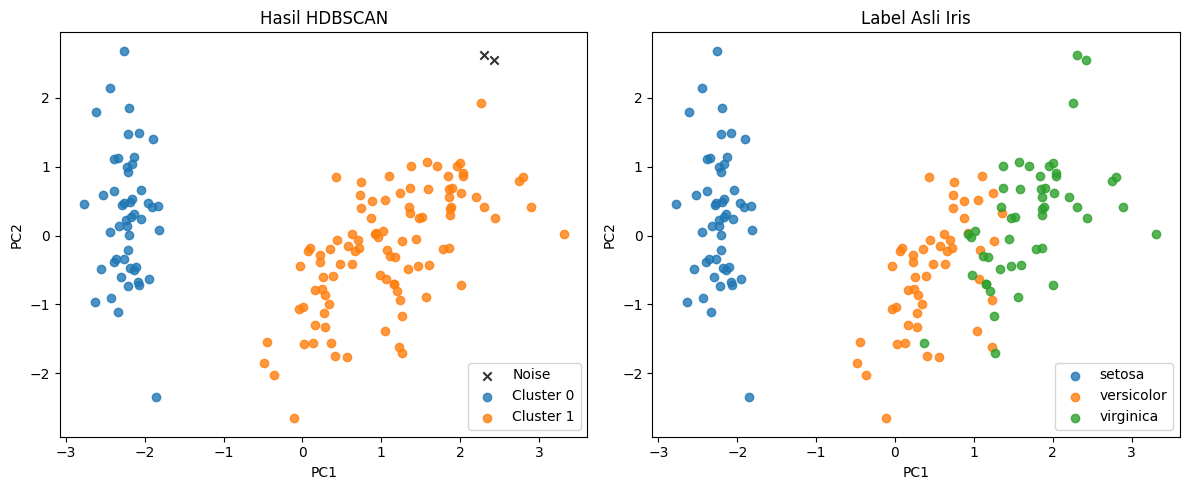

In [5]:
Xp = PCA(n_components=2).fit_transform(Xs)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Hasil HDBSCAN
for k in np.unique(labels):
    s = labels == k
    ax[0].scatter(Xp[s, 0], Xp[s, 1],
                  label="Noise" if k == -1 else f"Cluster {k}",
                  c="k" if k == -1 else None,
                  marker="x" if k == -1 else "o", alpha=.8)
ax[0].set_title("Hasil HDBSCAN")
ax[0].legend()

# Label asli
for k, name in enumerate(iris.target_names):
    s = y == k
    ax[1].scatter(Xp[s, 0], Xp[s, 1], label=name, alpha=.8)
ax[1].set_title("Label Asli Iris")
ax[1].legend()

for a in ax:
    a.set_xlabel("PC1")
    a.set_ylabel("PC2")

plt.tight_layout()
plt.show()

## 5. Analisis

**Ringkasan hasil:**

| Label asli | Noise (-1) | Cluster 0 | Cluster 1 |
|---|---|---|---|
| setosa | 0 | 50 | 0 |
| versicolor | 0 | 0 | 50 |
| virginica | 2 | 0 | 48 |

- Jumlah cluster: **2**
- Jumlah noise: **2 titik**
- ARI ≈ **0.56**, NMI ≈ **0.72**

**Apakah sesuai dengan label asli?**
Hasil HDBSCAN **tidak sepenuhnya sesuai** dengan label asli. Iris memiliki 3 kelas, namun HDBSCAN hanya membentuk 2 cluster:

1. **Setosa** terpisah sempurna menjadi satu cluster sendiri karena posisinya di ruang fitur memang terpisah jelas dari dua spesies lainnya.
2. **Versicolor dan virginica tergabung** dalam satu cluster karena kedua kelas ini saling tumpang tindih di ruang fitur, sehingga tidak ada pemisah densitas yang cukup jelas.
3. **Noise hanya 2 titik** (keduanya virginica), yaitu titik pencilan yang letaknya jauh dari kerumunan utama.

**Kesimpulan:**
HDBSCAN mengelompokkan data berdasarkan perbedaan **kepadatan (densitas)**, bukan berdasarkan label kelas. Algoritma ini efektif memisahkan struktur dengan densitas yang berbeda jelas (setosa vs lainnya), tetapi tidak mampu memisahkan kelas yang saling overlap. Nilai ARI yang sedang (~0.56) mencerminkan hal tersebut: clustering sebagian cocok dengan label asli, namun tidak merepresentasikan 3 spesies secara utuh.